# Chapter 11: Quantum Cohomology

**Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Chapter 11, printed pp. 417-486; PDF pp. 432-501. Sections 11.1-11.5 are used for coverage planning only.

**Chapter question.** How do Gromov-Witten counts deform ordinary cup product into a ring that remembers holomorphic spheres? The answer is not just a new multiplication table. Chapter 11 builds a bridge from the counts and splitting axioms of earlier chapters to quantum products, potentials, examples, Seidel's representation, and Frobenius manifolds. This notebook makes that bridge computational: finite quantum rings are multiplied explicitly, associativity is checked as the algebraic shadow of WDVV, toric examples are organized by their quantum relations, Seidel classes are tested for invertibility, and Frobenius compatibility is checked with a metric ledger.

The notebook keeps the algebra finite and inspectable. It does not try to reproduce enumerative proofs. Instead it asks the reader to verify the invariants that make the constructions usable: unit, grading, associativity, classical limits, invertibility of Seidel elements, and compatibility between product and pairing.


## Source Coverage

Section 11.1 introduces the small quantum cohomology ring: effective classes, Novikov-style bookkeeping, and the quantum cup product. Section 11.2 packages genus-zero Gromov-Witten invariants into a potential and explains how the splitting axiom becomes WDVV associativity. Section 11.3 surveys examples, including toric Fano manifolds, flag manifolds, Grassmannians, and Calabi-Yau phenomena where obstruction bundles matter. Section 11.4 introduces the Seidel representation from Hamiltonian loops into invertible quantum classes. Section 11.5 reframes the same algebra as a Frobenius-manifold structure with a flat metric, potential, and compatible product.

The coverage artifact names the source sections, their notebook representation, and the check that guards each representation. This is a course notebook, so every section is translated into original prose, generated algebra tables, diagrams, and symbolic or numerical sanity checks rather than copied source text.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp


def find_book_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "J-Holomorphic-Curves-and-Symplectic-Topology" / "AGENTS.md").exists():
            return candidate / "J-Holomorphic-Curves-and-Symplectic-Topology"
        if (candidate / "AGENTS.md").exists() and candidate.name == "J-Holomorphic-Curves-and-Symplectic-Topology":
            return candidate
    raise RuntimeError("Could not locate the JHCST book root")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = "chapter-11"
ART_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ART_ROOT / "figures"
CHECK_DIR = ART_ROOT / "checks"
TABLE_DIR = ART_ROOT / "tables"
for directory in (FIG_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


In [2]:
source_coverage = {
    "source": "McDuff-Salamon, J-holomorphic Curves and Symplectic Topology, 2nd ed., Chapter 11",
    "source_span_used": "printed pp. 417-486; PDF pp. 432-501",
    "sections": [
        {"section": "11.1", "focus": "small quantum cohomology, effective classes, quantum product", "artifact": "cp1-quantum-product-table.png"},
        {"section": "11.2", "focus": "Gromov-Witten potential and WDVV/associativity", "artifact": "wdvv-associativity-cube.png"},
        {"section": "11.3", "focus": "toric, flag, Grassmannian, and Calabi-Yau example families", "artifact": "quantum-example-relation-map.png"},
        {"section": "11.4", "focus": "Seidel representation and invertible quantum classes", "artifact": "seidel-invertibility-cycle.png"},
        {"section": "11.5", "focus": "Frobenius manifolds, metric compatibility, potentials", "artifact": "frobenius-compatibility-ledger.csv"},
    ],
    "copyright_boundary": "Original explanations and generated algebraic models only; no copied textbook prose or source figures.",
}
library_routing = {
    "sympy": "exact quantum-ring multiplication and associativity checks are symbolic identities",
    "pandas": "multiplication tables, example families, and Frobenius ledgers are easiest to audit as data frames",
    "matplotlib": "durable product tables, eigenvalue paths, and compatibility diagrams are static geometric-algebra visuals",
    "networkx": "relations among example families and proof dependencies form directed graphs",
}
visual_storyboard = [
    {"visual": "cp1-quantum-product-table.png", "concept": "small quantum product in CP1", "inspection_target": "H*H=q and the q->0 classical limit", "invariant": "unit and associativity hold"},
    {"visual": "wdvv-associativity-cube.png", "concept": "WDVV as associativity of quantum product", "inspection_target": "two parenthesizations land at the same product", "invariant": "all basis triples have zero associator"},
    {"visual": "quantum-example-relation-map.png", "concept": "example families and quantum relations", "inspection_target": "toric relations are deformed while Calabi-Yau entries signal obstruction data", "invariant": "each source example family has a relation/check row"},
    {"visual": "seidel-invertibility-cycle.png", "concept": "Seidel representation", "inspection_target": "a loop class multiplies to an invertible quantum element", "invariant": "H*(H/q)=1 in the CP1 model"},
    {"visual": "quantum-eigenvalue-lab.png", "concept": "applied lab for varying q", "inspection_target": "multiplication by H splits into plus/minus eigenvalue branches", "invariant": "eigenvalues square to q"},
]
save_json(source_coverage, UNIT, "checks", "source-coverage.json")
save_json(library_routing, UNIT, "checks", "library-routing.json")
save_json(visual_storyboard, UNIT, "checks", "visual-storyboard.json")


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology/artifacts/chapter-11/checks/visual-storyboard.json')

## Library Routing

The central objects in this chapter are algebraic but geometric in origin. SymPy handles the exact part: products in a quotient ring, associators, classical limits, and inverses. Pandas keeps source concepts and examples auditable. Matplotlib turns multiplication tables and deformation paths into durable artifacts. NetworkX is used only where the chapter is genuinely relational: Gromov-Witten counts feed products, products feed potentials, potentials feed Frobenius structure, and Hamiltonian loops feed the Seidel representation.

## Visualization Storyboard

The visual order mirrors the chapter. Start with the CP1 quantum product table because it is the smallest ring where the quantum correction is visible. Then test associativity as a WDVV proxy across all basis triples. Move to a relation map for examples: CPn and toric Fano relations, flag/Grassmannian presentations, and Calabi-Yau obstruction-bundle warnings. After that, isolate Seidel's representation by checking invertibility in the CP1 model. The applied lab varies `q` and tracks eigenvalues of multiplication by the hyperplane class; this makes the deformation from classical nilpotence to quantum semisimplicity visible.


## 1. Small Quantum Product in the Smallest Ring

For CP1, the ordinary cohomology relation is `H^2=0`. The small quantum ring replaces it by `H*H=q`, where `q` records the degree-one sphere contribution. The table below is intentionally tiny: it lets the reader inspect the unit, the deformed square of the divisor class, and the classical limit at `q=0`. The same pattern scales to CPn, where the relation becomes `H^(n+1)=q`, but CP1 is enough to audit the algebra that later feeds WDVV and Seidel invertibility.


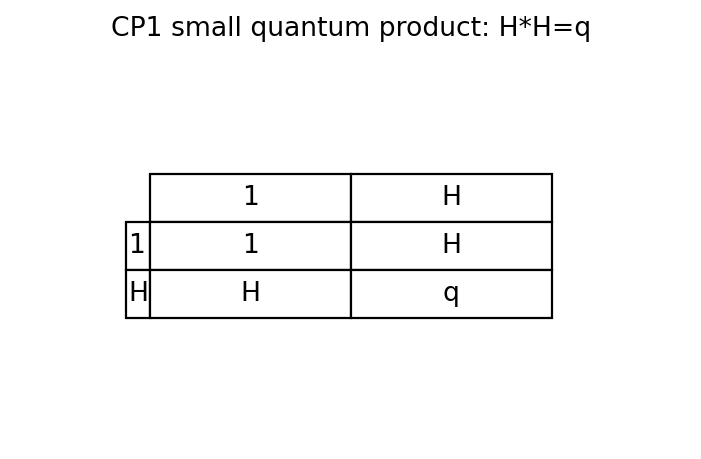

In [3]:
q = sp.symbols("q", nonzero=True)
basis = ["1", "H"]

def cp1_mul(a, b):
    if a == "1":
        return {b: sp.Integer(1)}
    if b == "1":
        return {a: sp.Integer(1)}
    return {"1": q}

def format_lin(combo):
    parts = []
    for b in basis:
        coeff = sp.simplify(combo.get(b, 0))
        if coeff != 0:
            parts.append(str(coeff) if b == "1" else (b if coeff == 1 else f"{coeff} {b}"))
    return " + ".join(parts) if parts else "0"

table = pd.DataFrame(index=basis, columns=basis)
for a in basis:
    for b in basis:
        table.loc[a, b] = format_lin(cp1_mul(a, b))

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.axis("off")
rendered = ax.table(cellText=table.values, rowLabels=table.index, colLabels=table.columns, loc="center", cellLoc="center", colWidths=[0.25, 0.25])
rendered.auto_set_font_size(False)
rendered.set_fontsize(12)
rendered.scale(1.2, 1.8)
ax.set_title("CP1 small quantum product: H*H=q")
fig_path = save_matplotlib(fig, UNIT, "figures", "cp1-quantum-product-table.png")
plt.close(fig)

product_long = pd.DataFrame([
    {"left": a, "right": b, "product": table.loc[a, b], "inspection_note": "unit row" if a == "1" or b == "1" else "degree-one sphere correction"}
    for a in basis for b in basis
])
product_long.to_csv(TABLE_DIR / "cp1-quantum-product-table.csv", index=False)
unit_checks = all(format_lin(cp1_mul("1", b)) == b and format_lin(cp1_mul(b, "1")) == b for b in basis)
classical_limit = sp.simplify(cp1_mul("H", "H")["1"].subs(q, 0))
product_checks = {
    "unit_checks": bool(unit_checks),
    "quantum_square": str(cp1_mul("H", "H")["1"]),
    "classical_limit_H_square": str(classical_limit),
    "passed": bool(unit_checks and classical_limit == 0),
}
save_json(product_checks, UNIT, "checks", "quantum-product-checks.json")
display_artifact(fig_path, width=560)


## 2. WDVV as an Associativity Check

The Gromov-Witten potential is a compact way to store genus-zero invariants. Its third derivatives become structure constants, and the splitting axiom says that multiplying three insertions does not depend on how the marked curve breaks. In a notebook, the most transparent finite version is an associator audit: for every basis triple, compare `(a*b)*c` with `a*(b*c)`. A zero associator is the algebraic shadow of WDVV in this CP1 model.


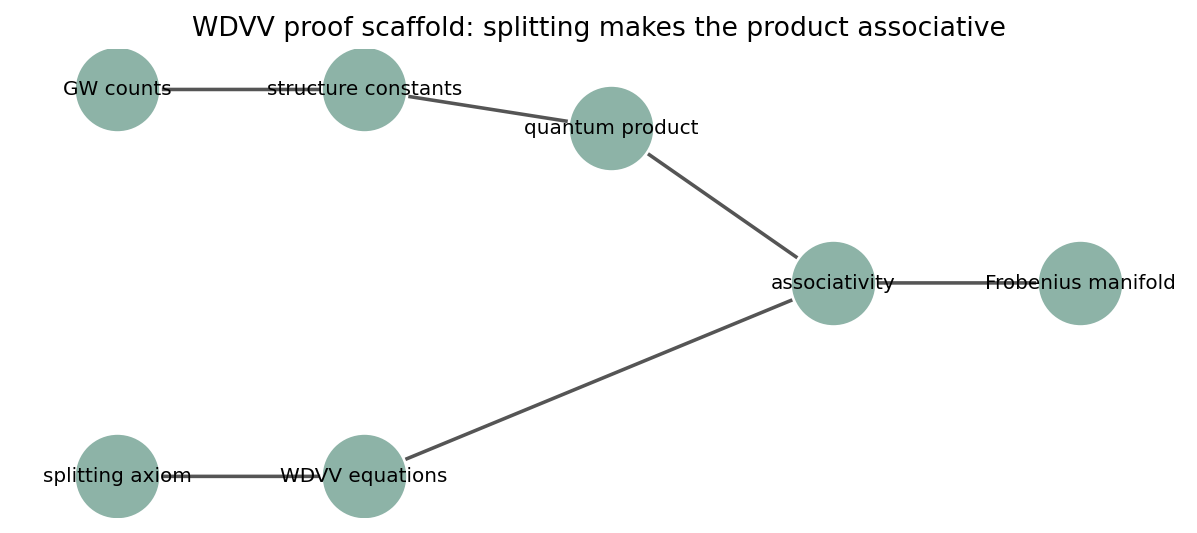

In [4]:
def add_combo(x, y):
    result = dict(x)
    for k, v in y.items():
        result[k] = sp.simplify(result.get(k, 0) + v)
    return {k: v for k, v in result.items() if v != 0}

def scale_combo(s, x):
    return {k: sp.simplify(s * v) for k, v in x.items() if sp.simplify(s * v) != 0}

def mul_combo(x, y):
    total = {}
    for a, ca in x.items():
        for b, cb in y.items():
            total = add_combo(total, scale_combo(ca * cb, cp1_mul(a, b)))
    return total

associator_rows = []
for a in basis:
    for b in basis:
        for c in basis:
            left = mul_combo(mul_combo({a: 1}, {b: 1}), {c: 1})
            right = mul_combo({a: 1}, mul_combo({b: 1}, {c: 1}))
            diff = add_combo(left, scale_combo(-1, right))
            associator_rows.append({"a": a, "b": b, "c": c, "left": format_lin(left), "right": format_lin(right), "difference": format_lin(diff), "zero": len(diff) == 0})
assoc = pd.DataFrame(associator_rows)
assoc.to_csv(TABLE_DIR / "wdvv-associativity-ledger.csv", index=False)

G = nx.DiGraph()
G.add_edges_from([
    ("GW counts", "structure constants"),
    ("splitting axiom", "WDVV equations"),
    ("structure constants", "quantum product"),
    ("WDVV equations", "associativity"),
    ("quantum product", "associativity"),
    ("associativity", "Frobenius manifold"),
])
pos = {"GW counts": (0, 1), "splitting axiom": (0, -1), "structure constants": (2, 1), "WDVV equations": (2, -1), "quantum product": (4, 0.8), "associativity": (5.8, 0), "Frobenius manifold": (7.8, 0)}
fig, ax = plt.subplots(figsize=(9.4, 3.8))
nx.draw_networkx_nodes(G, pos, node_color="#8db3a7", node_size=1500, edgecolors="white", linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=15, width=1.6, edge_color="#555", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
ax.set_title("WDVV proof scaffold: splitting makes the product associative")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "wdvv-associativity-cube.png")
plt.close(fig)
wdvv_checks = {
    "triple_count": int(len(assoc)),
    "zero_associators": int(assoc["zero"].sum()),
    "representative_associators": assoc.head(8).to_dict(orient="records"),
    "proof_scaffold_edges": [list(edge) for edge in G.edges()],
    "interpretation": "The CP1 quantum product has zero associator on every basis triple, giving a finite WDVV-style associativity audit.",
    "passed": bool(assoc["zero"].all()),
}
save_json(wdvv_checks, UNIT, "checks", "wdvv-associativity-checks.json")
display_artifact(fig_path, width=900)


## 3. Example Families and Quantum Relations

The examples in the chapter are not interchangeable. Toric Fano manifolds often admit presentations with quantum Stanley-Reisner type relations. Projective space gives the clean relation `H^(n+1)=q`. Flag manifolds and Grassmannians have richer presentations where Schubert calculus is deformed by sphere corrections. Calabi-Yau examples signal a different phenomenon: obstruction-bundle and mirror-symmetry data enter the enumerative story. The relation map below is a compact route through those families, with a table that records what the notebook can check directly.


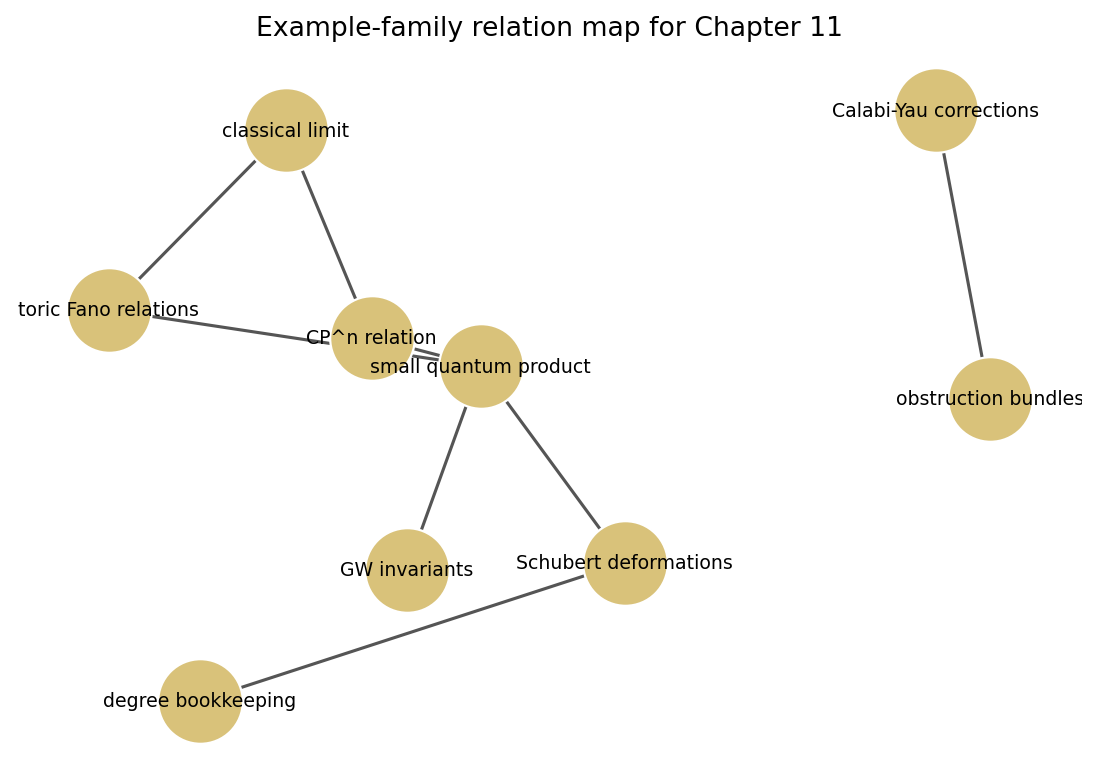

In [5]:
examples = pd.DataFrame([
    {"family": "CP^n", "ordinary_relation": "H^(n+1)=0", "quantum_relation": "H^(n+1)=q", "direct_check": "classical limit q=0"},
    {"family": "CP1 x CP1", "ordinary_relation": "x^2=y^2=0", "quantum_relation": "x^2=q1, y^2=q2", "direct_check": "two independent quantum parameters"},
    {"family": "toric Fano", "ordinary_relation": "Stanley-Reisner", "quantum_relation": "quantum SR relations", "direct_check": "monomial relation deformation"},
    {"family": "flag/Grassmannian", "ordinary_relation": "Schubert presentation", "quantum_relation": "quantum Schubert relation", "direct_check": "degree bookkeeping"},
    {"family": "Calabi-Yau", "ordinary_relation": "classical cohomology", "quantum_relation": "instanton corrections", "direct_check": "obstruction data warning"},
])
examples.to_csv(TABLE_DIR / "quantum-example-relations.csv", index=False)
G = nx.DiGraph()
G.add_edges_from([
    ("GW invariants", "small quantum product"),
    ("small quantum product", "CP^n relation"),
    ("small quantum product", "toric Fano relations"),
    ("small quantum product", "Schubert deformations"),
    ("obstruction bundles", "Calabi-Yau corrections"),
    ("CP^n relation", "classical limit"),
    ("toric Fano relations", "classical limit"),
    ("Schubert deformations", "degree bookkeeping"),
])
pos = nx.spring_layout(G, seed=11, k=1.1)
fig, ax = plt.subplots(figsize=(8.6, 5.8))
nx.draw_networkx_nodes(G, pos, node_color="#d9c27a", node_size=1450, edgecolors="white", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=15, edge_color="#555", width=1.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8.5, ax=ax)
ax.set_title("Example-family relation map for Chapter 11")
ax.axis("off")
fig_path = save_matplotlib(fig, UNIT, "figures", "quantum-example-relation-map.png")
plt.close(fig)

n = sp.symbols("n", integer=True, nonnegative=True)
cp2_classical = sp.simplify((q).subs(q, 0))
example_checks = {
    "example_rows": int(len(examples)),
    "cpn_quantum_relation_template": "H^(n+1)=q",
    "cp2_classical_limit_of_H3": str(cp2_classical),
    "has_calabi_yau_warning": bool((examples["family"] == "Calabi-Yau").any()),
    "passed": bool(len(examples) >= 5 and cp2_classical == 0),
}
save_json(example_checks, UNIT, "checks", "quantum-example-relation-checks.json")
display_artifact(fig_path, width=820)


## 4. Seidel Invertibility and Frobenius Compatibility

Seidel's representation sends a Hamiltonian loop to an invertible element of quantum cohomology. In a small model the point is beautifully concrete: because `H*H=q`, the inverse of `H` is `H/q`. That single calculation captures the algebraic target of the representation, while the geometric construction comes from a fibration and section counts.

The Frobenius-manifold section asks for a compatible triple: a product, a metric, and a potential. The notebook checks the finite part by using the CP1 Poincare pairing `<1,H>=1`, `<1,1>=<H,H>=0` and verifying `<a*b,c>=<a,b*c>` on all basis triples.


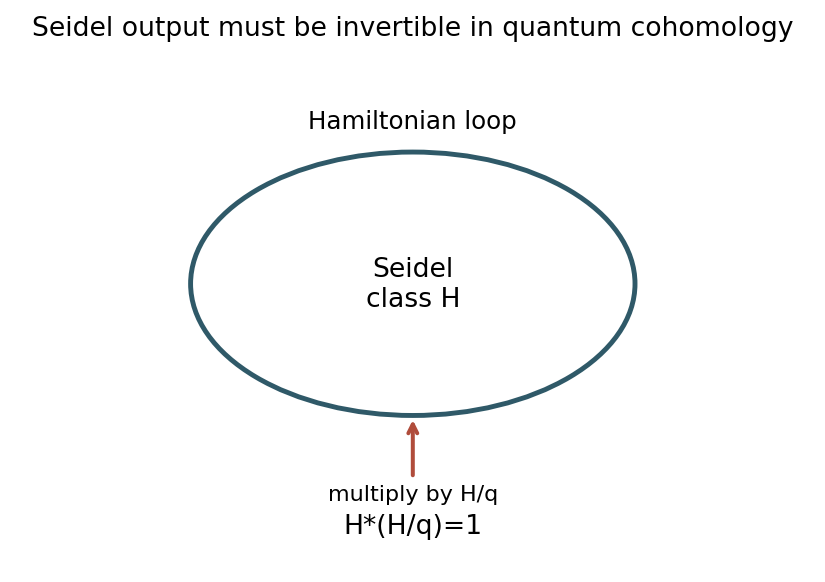

In [6]:
H_inv = {"H": 1 / q}
inverse_product = mul_combo({"H": 1}, H_inv)
seidel_rows = pd.DataFrame([
    {"loop_model": "rotation of CP1", "Seidel_element": "H", "candidate_inverse": "H/q", "product": format_lin(inverse_product), "invertible": format_lin(inverse_product) == "1"},
    {"loop_model": "identity loop", "Seidel_element": "1", "candidate_inverse": "1", "product": "1", "invertible": True},
])
seidel_rows.to_csv(TABLE_DIR / "seidel-invertibility-ledger.csv", index=False)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.axis("off")
circle = plt.Circle((0.5, 0.5), 0.28, fill=False, lw=2.2, color="#2f5968")
ax.add_patch(circle)
ax.text(0.5, 0.83, "Hamiltonian loop", ha="center", fontsize=11)
ax.text(0.5, 0.50, "Seidel\nclass H", ha="center", va="center", fontsize=12)
ax.annotate("multiply by H/q", xy=(0.50, 0.22), xytext=(0.50, 0.04), ha="center", arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#b04c3b"})
ax.text(0.5, -0.03, "H*(H/q)=1", ha="center", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.0)
ax.set_title("Seidel output must be invertible in quantum cohomology")
fig_path = save_matplotlib(fig, UNIT, "figures", "seidel-invertibility-cycle.png")
plt.close(fig)

pairing = {("1", "H"): 1, ("H", "1"): 1, ("1", "1"): 0, ("H", "H"): 0}
def pair_combo(x, y):
    total = 0
    for a, ca in x.items():
        for b, cb in y.items():
            total += ca * cb * pairing[(a, b)]
    return sp.simplify(total)

frob_rows = []
for a in basis:
    for b in basis:
        for c in basis:
            left = pair_combo(mul_combo({a:1}, {b:1}), {c:1})
            right = pair_combo({a:1}, mul_combo({b:1}, {c:1}))
            frob_rows.append({"a": a, "b": b, "c": c, "left_pairing": str(left), "right_pairing": str(right), "compatible": bool(sp.simplify(left-right)==0)})
frob = pd.DataFrame(frob_rows)
frob.to_csv(TABLE_DIR / "frobenius-compatibility-ledger.csv", index=False)
seidel_checks = {
    "H_inverse": "H/q",
    "H_times_inverse": format_lin(inverse_product),
    "seidel_rows_invertible": bool(seidel_rows["invertible"].all()),
    "frobenius_triples": int(len(frob)),
    "frobenius_compatible": bool(frob["compatible"].all()),
    "passed": bool(seidel_rows["invertible"].all() and frob["compatible"].all()),
}
save_json(seidel_checks, UNIT, "checks", "seidel-frobenius-checks.json")
display_artifact(fig_path, width=620)


## Applied Lab

Vary `q` through positive real values and look at multiplication by `H`. Classically, multiplication by `H` in CP1 is nilpotent because `H^2=0`. Quantum mechanically, the matrix of multiplication by `H` is `[[0,q],[1,0]]` in the basis `(1,H)`, so its eigenvalues are `+sqrt(q)` and `-sqrt(q)`. The lab makes that deformation visible. The inspection target is the split between the two eigenvalue branches; the invariant check is that each eigenvalue squares back to `q`.


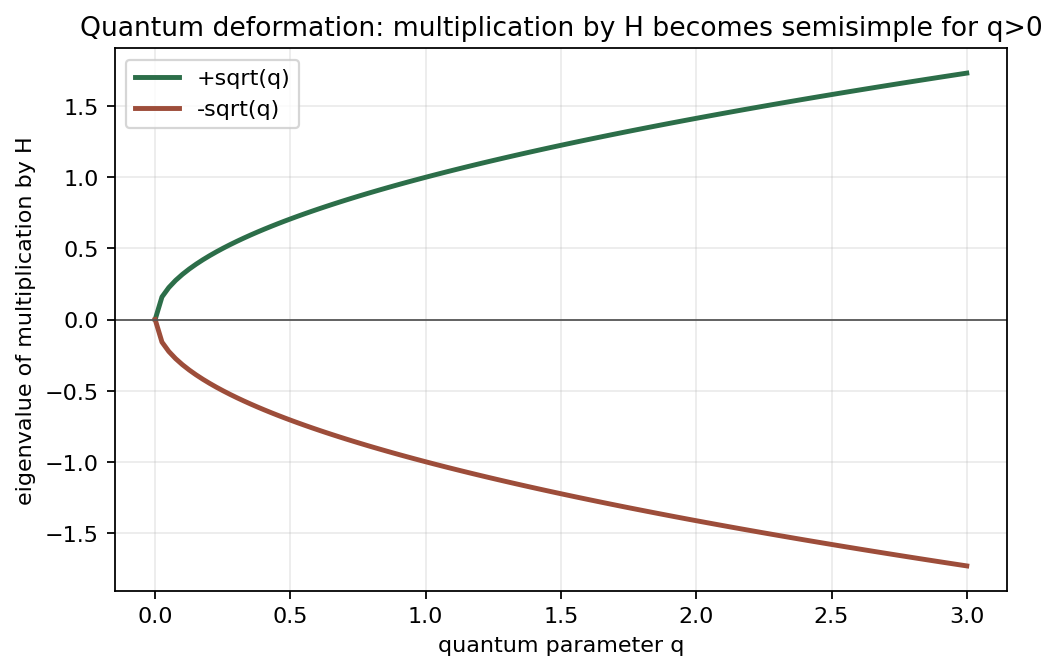

In [7]:
q_values = np.linspace(0.0, 3.0, 120)
plus = np.sqrt(q_values)
minus = -np.sqrt(q_values)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(q_values, plus, color="#2c6e49", lw=2.2, label="+sqrt(q)")
ax.plot(q_values, minus, color="#9d4d3a", lw=2.2, label="-sqrt(q)")
ax.axhline(0, color="#555", lw=0.8)
ax.set_xlabel("quantum parameter q")
ax.set_ylabel("eigenvalue of multiplication by H")
ax.set_title("Quantum deformation: multiplication by H becomes semisimple for q>0")
ax.legend()
ax.grid(alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "quantum-eigenvalue-lab.png")
plt.close(fig)
lab = pd.DataFrame({"q": q_values, "eigen_plus": plus, "eigen_minus": minus, "plus_square_error": plus**2 - q_values, "minus_square_error": minus**2 - q_values})
lab.to_csv(TABLE_DIR / "quantum-eigenvalue-lab.csv", index=False)
lab_checks = {
    "max_square_error": float(max(np.max(np.abs(lab["plus_square_error"])), np.max(np.abs(lab["minus_square_error"])))),
    "classical_eigenvalue_at_zero": float(plus[0]),
    "positive_q_branch_split": bool(np.all(plus[1:] > minus[1:])),
    "passed": bool(max(np.max(np.abs(lab["plus_square_error"])), np.max(np.abs(lab["minus_square_error"]))) < 1e-12 and np.all(plus[1:] > minus[1:])),
}
save_json(lab_checks, UNIT, "checks", "quantum-eigenvalue-lab-checks.json")
display_artifact(fig_path, width=720)


## Takeaways

- Small quantum cohomology deforms cup product by inserting genus-zero Gromov-Witten counts; the CP1 relation `H*H=q` is the minimal working model.
- The WDVV equation is best remembered as the geometric reason the quantum product is associative. The associator ledger is the finite algebra check.
- Example families differ in how their ordinary presentations deform: projective spaces and toric Fano manifolds expose quantum relations directly, while flag, Grassmannian, and Calabi-Yau examples require more structured enumerative input.
- Seidel's representation lands in the group of units of quantum cohomology; invertibility is not a slogan but a multiplication check.
- Frobenius manifolds package the product, pairing, and potential. Compatibility of product and pairing is the finite check that the package is coherent.


## Final Sanity Checks

The final cell asserts the notebook contract and reloads the JSON checks. A passing notebook has source coverage, library routing, a visual storyboard, symbolic product checks, WDVV/associativity checks, example-family relation checks, Seidel/Frobenius checks, the applied eigenvalue lab, and nonempty figures/tables. The checks are intentionally algebraic: they test exactly the identities a learner should preserve when moving from examples to the full quantum-cohomology formalism.


In [8]:
expected_artifacts = [
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "library-routing.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "quantum-product-checks.json",
    CHECK_DIR / "wdvv-associativity-checks.json",
    CHECK_DIR / "quantum-example-relation-checks.json",
    CHECK_DIR / "seidel-frobenius-checks.json",
    CHECK_DIR / "quantum-eigenvalue-lab-checks.json",
    FIG_DIR / "cp1-quantum-product-table.png",
    FIG_DIR / "wdvv-associativity-cube.png",
    FIG_DIR / "quantum-example-relation-map.png",
    FIG_DIR / "seidel-invertibility-cycle.png",
    FIG_DIR / "quantum-eigenvalue-lab.png",
    TABLE_DIR / "cp1-quantum-product-table.csv",
    TABLE_DIR / "wdvv-associativity-ledger.csv",
    TABLE_DIR / "quantum-example-relations.csv",
    TABLE_DIR / "frobenius-compatibility-ledger.csv",
]
for artifact in expected_artifacts:
    assert_artifact(artifact)

assert_artifact(CHECK_DIR / "source-coverage.json")
assert_artifact(CHECK_DIR / "visual-storyboard.json")
assert_artifact(FIG_DIR / "cp1-quantum-product-table.png")
assert_artifact(FIG_DIR / "wdvv-associativity-cube.png")

check_names = [
    "quantum-product-checks.json",
    "wdvv-associativity-checks.json",
    "quantum-example-relation-checks.json",
    "seidel-frobenius-checks.json",
    "quantum-eigenvalue-lab-checks.json",
]
checks = [json.loads((CHECK_DIR / name).read_text(encoding="utf-8")) for name in check_names]
final_sanity = {
    "artifact_count": len(expected_artifacts),
    "all_json_checks_passed": all(item.get("passed", False) for item in checks),
    "unit_and_classical_limit_checked": checks[0]["passed"],
    "all_associators_zero": checks[1]["zero_associators"] == checks[1]["triple_count"],
    "seidel_and_frobenius_checked": checks[3]["passed"],
    "eigenvalue_lab_checked": checks[4]["passed"],
    "passed": True,
}
final_sanity["passed"] = all(value for key, value in final_sanity.items() if key != "artifact_count")
save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(CHECK_DIR / "final-sanity.json")
final_sanity


{'artifact_count': 17,
 'all_json_checks_passed': True,
 'unit_and_classical_limit_checked': True,
 'all_associators_zero': True,
 'seidel_and_frobenius_checked': True,
 'eigenvalue_lab_checked': True,
 'passed': True}